# Support Vector Machine (SVM)

Uno de los problemas típicos en Machine Learning es clasificar los datos de entrada en distintos grupos. El modelo Support Vector Machine (SVM) es uno de los más utilizados en la actualidad para la toma de decisiones.    

Los ámbitos en que se utiliza es el diagnóstico de enfermedades (enfermo/sano), clasificación de correos electrónicos (interesante/spam), reconocimiento y clasificación de imágenes, bioinformática, detección de anomalías, ...

## Concepto    

Para comprender cómo funciona desde un punto de vista intuitivo vamos a suponer que trabajamos en un espacio bidimensional, con dos variables X1 y X2.   

<img src="img/Variable-1.jpg" width=500>

Queremos dividir el conjunto de observaciones en dos clases, rojo y verde. ¿Cómo se podría realizar?   

<img src="img/Variable-2.jpg" width=500>

De forma intuitiva, se puede ver que existen múltiples rectas que dividen en dos el conjunto de observaciones.    

Utilizar una u otra tendrá consecuencias respecto a cómo se clasifican las observaciones para las que no disponemos información inicial. Intentar elegir la línea óptima es lo que busca SVM.   

<img src="img/variable-3.jpg" width=500>

Con SVM la línea se busca a través del margen máximo de los dos puntos más cercanos de la muestra, que se denominan vectores de soporte.    
Se traza a la misma distancia entre ellos. La suma de las distancias entre ellos debe ser maximizada. Una vez seleccionados, el resto de puntos de la muestra no son significativos para el resultado del mismo. 

La línea que divide las clases recibe el nombre de **Hiperplano**, por la generalización que se hace para espacios multidimensionales.

SVM toma una estrategia diferente a otros algoritmos de clasificación dentro del Machine Learning. En lugar de centrarse en tomar aquellos elementos más representativos de la muestra y comparar las entradas nuevas con ellos, centra la atención en aquellos elementos que más se parecen y que marcan la diferencia.    

Se centra en los elementos cuya identificación puede ser más confusa por ser más parecidos entre sí.

## Ejemplo: Clientes potenciales de un nuevo modelo de bicicleta.   

Para el ejemplo disponemos de un conjunto de observaciones de clientes que han visto el anuncio de un nuevo modelo de bicicleta en redes sociales. Disponemos de un fichero en formato CSV con la edad de la persona que ha visto el anuncio, junto a su salario estimado y si ha comprado o no la bicicleta.

El objetivo es *dividir al conjunto de clientes posibles entre aquellos que es posible que compren nuestro producto y los que es menos probable que lo hagan*, para tomar decisiones de cara al público objetivo de futuras campañas de marketing.

## Importar librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importando dataset

In [2]:
dataset = pd.read_csv('C:/Users/Jose Manuel/Documents/VisualStudioCode_Workspace/Repo_CEDAPY/CEDAPY_25_26/ANALISIS_DATOS_PYTHON/NOTEBOOKS/MACHINE_LEARNING/APRENDIZAJE_SUPERVISADO\datasets/anuncio_red_social.csv')


In [3]:
dataset.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


### Ajuste de datos y características.

En este bloque de código reajustamos los tipos de dato de las características a analizar (Salario y Comprada), generando nuevas características con los datos acomodados al nuevo tipo.    
En el último paso, eliminamos las columnas originales y dejamos el dataset definitivo con el que realizaremos el experimento.

In [4]:
dataset.drop(['User ID','Gender'],axis=1,inplace=True )
dataset.rename(columns={'EstimatedSalary':'Salario_estimado','Age':'Edad','Purchased':'Comprada'}, inplace=True)
dataset.head()

,Edad,Salario_estimado,Comprada
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [5]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

## Dividimos el dataset en los conjuntos de Train y Test.

Leemos los datos del fichero CSV. En este caso tenemos en X una matriz con las dos columnas correspondientes a las variables de entrada: edad y salario estimado. Dividimos mediante la función train_test_split los datos de entrada entre conjunto de entrenamiento (75%) y conjunto de test (25%). Esto nos servirá para evaluar cómo de bueno es el modelo entrenado sobre datos de los que disponemos. 

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

# Feature scalling

**Feature scaling** es importante en SVM porque ayuda a que todas las variables de entrada tengan la misma importancia. Esto es clave porque SVM se basa en la distancia entre los puntos de datos. Si las características no están escaladas, los puntos de datos con valores más grandes tendrán una mayor influencia en la ubicación de la frontera de decisión. 

En nuestro ejemplo, el *salario estimado* tiene valores mucho mayores que la *edad*. Si no aplicamos **feature scaling**, el modelo le daría mucha más importancia al salario que a la edad.



In [7]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [8]:
print(X_train);
print(X_test);

[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]
 [-0.60673761  1.89663484]
 [ 1.37390747 -1.40858358]
 [ 1.47293972  0.99784738]
 [ 0.08648817 -0.79972756]
 [-0.01254409 -0.24885782]
 [-0.21060859 -0.5677824 ]
 [-0.21060859 -0.19087153]
 [-0.30964085 -1.29261101]
 [-0.30964085 -0.5677824 ]
 [ 0.38358493  0.09905991]
 [ 0.8787462  -0.59677555]
 [ 2.06713324 -1.17663843]
 [ 1.07681071 -0.13288524]
 [ 0.68068169  1.78066227]
 [-0.70576986  0.56295021]
 [ 0.77971394  0.35999821]
 [ 0.8787462  -0.53878926]
 [-1.20093113 -1.58254245]
 [ 2.1661655   0.93986109]
 [-0.01254409  1.22979253]
 [ 0.18552042  1.08482681]
 [ 0.38358493 -0.48080297]
 [-0.30964085 -0.30684411]
 [ 0.97777845 -0.8287207 ]
 [ 0.97777845  1.8676417 ]
 [-0.01254409  1.25878567]
 [-0.90383437  2.27354572]
 [-1.20093113 -1.58254245]
 [ 2.1661655  -0.79972756]
 [-1.39899564 -1.46656987]
 [ 0.38358493  2.30253886]
 [ 0.77971394  0.76590222]
 [-1.00286662 -0.30684411]
 [ 0.08648817  0.76590222]
 

Utilizamos la clase *StandadScaller* de scikit-learn, con lo que obtenemos una nueva matriz de datos donde tanto salario y como edad están en una escala común. 

## Entrenando el modelo SVM model sobre el conjunto de datos de entrenamiento

Utilizamos la clase SVC de la librería para entrenar el modelo, mediante el método `fit`.     
Utilizamos los datos de entrenamiento a los que previamente hemos aplicado la técnica de feature scaling. El algoritmo soporta distintos tipos de kernel en función de cómo queremos que se comporte la clasificación de puntos. Esto se indica en la creación del SVC.    

En nuestro caso elegimos lineal para que la separación sea una línea recta.

In [9]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'linear', random_state = 0)
classifier.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Predecir un nuevo resultado

Una vez entrenado el modelo podemos hacer predicciones de datos nuevos. Veamos la predicción para una persona que visualiza nuestro anuncio de bicicleta que tiene 25 años y cobra 24.000 euros anuales, va a adquirir el producto.¡

In [11]:
print(classifier.predict(sc.transform([[25,24000]])))

[0]


El resultado es 0, así que según el modelo SVN la persona NO va a comprar la bicicleta que estamos anunciando.

## Predecir salidas para los datos de prueba

Para hacer la predicción, lo primero que tenemos que hacer es aplicar *feature scaling* a la entrada, mediante la función `transform` del StandardScaler que tenemos configurado. Con los datos ya escalados llamamos a la función predict para obtener la predicción. 

Utilizamos los datos de prueba para hacer predicciones y compararlas con las salidas esperadas:

In [12]:
y_pred = classifier.predict(X_test);
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [1 1]
 [1 1]]


En la primera línea hacemos las predicciones a partir del conjunto de datos X_test.    
En la segunda preparamos una matriz donde la primera columna son las predicciones y la segunda son los valores reales.    

Podríamos examinar la salida para ver los casos en donde el SVM entrenado se equivoca en la predicción, pero sería bastante manual. Por ello veremos a continuación el concepto de matriz de confusión.

## Hacer la matriz de confusión

La matriz de confusión se utiliza para evaluar el rendimiento de un modelo de clasificación.

In [13]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("Accuracy: ",accuracy_score(y_test, y_pred))

[[66  2]
 [ 8 24]]
Accuracy:  0.9


Las filas representan los valores reales para la clasificación, las columnas los valores predichos. En este ejemplo tenemos:

- 66 valores donde la clasificación real es 0 y la predicción es 0.
- 24 valores donde la clasificación real es 1 y la predicción es 1.
- 2 falsos positivos (clasificación real es 0 y predicción es 1).
- 8 falsos negativos (clasificación real es 1 y predicción es 0).    

Con `accurancy_score` obtenemos la precisión del modelo, que en este caso es del 90%.

## Visualizar resultados del conjunto de datos de entrenamiento

C:\Users\Jose Manuel\AppData\Local\Temp\ipykernel_10132\2666530920.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('salmon', 'dodgerblue'))(i), label = j)


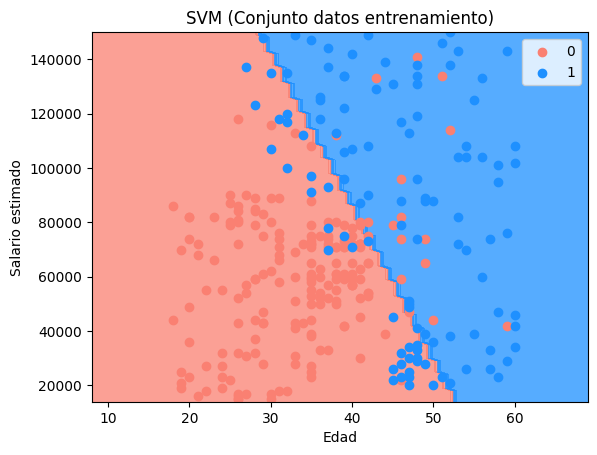

In [14]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1000))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('salmon', 'dodgerblue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('salmon', 'dodgerblue'))(i), label = j)
plt.title('SVM (Conjunto datos entrenamiento)')
plt.xlabel('Edad')
plt.ylabel('Salario estimado')
plt.legend()
plt.show()

## Visualizar resultados del conjunto de datos de prueba

C:\Users\Jose Manuel\AppData\Local\Temp\ipykernel_10132\3085792054.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('salmon', 'dodgerblue'))(i), label = j)


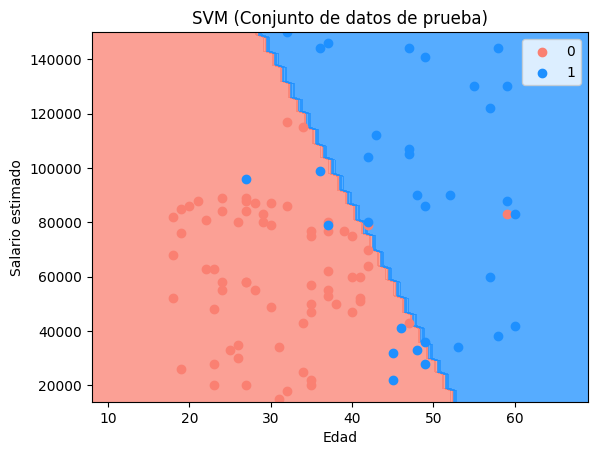

In [15]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1000))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('salmon', 'dodgerblue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('salmon', 'dodgerblue'))(i), label = j)
plt.title('SVM (Conjunto de datos de prueba)')
plt.xlabel('Edad')
plt.ylabel('Salario estimado')
plt.legend()
plt.show()

Vemos el hiperplano que divide el espacio de la muestra en dos partes:    
- En azul tenemos el área de los clientes para los que se predice que comprarán el nuevo modelo de bicicleta. 
- En rojo los que la predicción es que no la comprarán.     

Los puntos en las gráficas son los valores reales de la muestra de datos de entrada.

## Ejemplo: Reconocimiento facial.   

Como ejemplo del funcionamiento de las máquinas de vectores de soporte, veamos un problema de reconocimiento facial. Utilizaremos el conjunto de datos *Labeled Faces* in the Wild, que consta de varios miles de fotos recopiladas de diversas figuras públicas. Scikit-Learn incorpora un `fetcher` para el conjunto de datos:

In [16]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=60)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


Se muestran, a continuación, algunas de estas caras para ver con qué estamos trabajando:

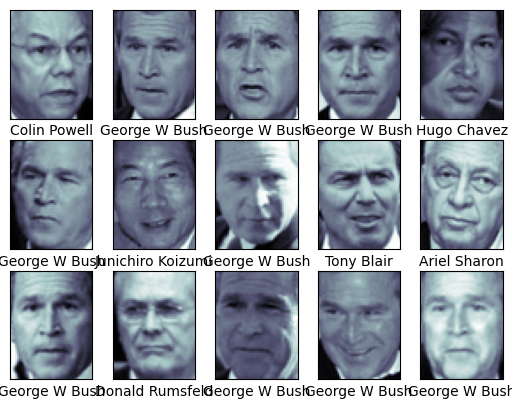

In [17]:
fig, ax = plt.subplots(3, 5)
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=faces.target_names[faces.target[i]])

Cada imagen contiene [62×47] o casi 3000 píxeles (2914, para ser exactos).     

Podríamos proceder simplemente utilizando cada valor de píxel como una característica, pero a menudo es más eficaz utilizar algún tipo de preprocesador para extraer características más significativas; aquí utilizaremos un análisis de componentes principales para extraer 150 componentes fundamentales que alimentarán nuestro clasificador de máquinas de vectores de soporte.    

Podemos hacerlo de la forma más sencilla agrupando el preprocesador y el clasificador en un único proceso:

In [18]:

from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

pca = PCA(n_components=150, whiten=True, random_state=42) # usamos PCA para reducir la dimensionalidad a 150 componentes
svc = SVC(kernel='rbf', class_weight='balanced') # SVC con kernel RBF y pesos equilibrados para manejar clases desbalanceadas
model = make_pipeline(pca, svc) # pipeline que combina PCA y SVC generando un modelo completo.

Con el fin de probar los resultados de nuestro clasificador, dividiremos los datos en un conjunto de entrenamiento y otro de prueba:

In [19]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(faces.data, faces.target,random_state=42)


Por último, podemos utilizar una validación cruzada de búsqueda por cuadrícula para explorar combinaciones de parámetros. Aquí ajustaremos **C** (que controla la dureza del margen) y gamma (que controla el tamaño del núcleo de la función de base radial) y determinaremos el mejor modelo:

In [20]:
from sklearn.model_selection import GridSearchCV
param_grid = {'svc__C': [1, 5, 10, 50],                     
              'svc__gamma': [0.0001, 0.0005, 0.001, 0.005]} 
grid = GridSearchCV(model, param_grid)

%time grid.fit(Xtrain, ytrain)
print(grid.best_params_)

CPU times: total: 1min 35s
Wall time: 25.6 s
{'svc__C': 5, 'svc__gamma': 0.001}


- **C** es el parámetro de regularización. Un valor más alto de C puede llevar a un modelo más complejo, mientras que un valor más bajo puede resultar en un modelo más simple.     
- **Gamma** es el parámetro del kernel RBF(Función de Base Radial)  que controla la influencia de cada punto de entrenamiento. Un valor más alto de gamma puede llevar a un modelo más complejo.

Los valores óptimos se sitúan hacia el centro de nuestra cuadrícula; si se situaran en los extremos, querríamos ampliar la cuadrícula para asegurarnos de haber encontrado el verdadero óptimo.

Ahora, con este modelo validado de forma cruzada, podemos predecir las etiquetas para los datos de prueba, que el modelo aún no ha visto:

In [21]:
model = grid.best_estimator_
yfit = model.predict(Xtest)

Echemos un vistazo a algunas de las imágenes de prueba junto con sus valores previstos:

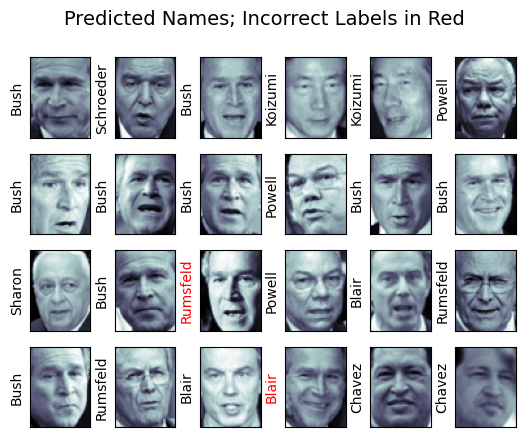

In [22]:
fig, ax = plt.subplots(4, 6)
for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(faces.target_names[yfit[i]].split()[-1],
                   color='black' if yfit[i] == ytest[i] else 'red')
fig.suptitle('Predicted Names; Incorrect Labels in Red', size=14);

De esta pequeña muestra, nuestro estimador óptimo solo etiquetó erróneamente dos caras (la cara de Bush en la penúltima fila, etiquetada como Rumsfeld y en la fila inferior se etiquetó también a Bush erróneamente como Blair). Podemos hacernos una idea más clara del rendimiento de nuestro estimador utilizando el informe de clasificación, que enumera las estadísticas de recuperación etiqueta por etiqueta:

In [23]:
from sklearn.metrics import classification_report
print(classification_report(ytest, yfit,
                            target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.65      0.87      0.74        15
     Colin Powell       0.83      0.88      0.86        68
  Donald Rumsfeld       0.70      0.84      0.76        31
    George W Bush       0.97      0.80      0.88       126
Gerhard Schroeder       0.76      0.83      0.79        23
      Hugo Chavez       0.93      0.70      0.80        20
Junichiro Koizumi       0.86      1.00      0.92        12
       Tony Blair       0.82      0.98      0.89        42

         accuracy                           0.85       337
        macro avg       0.82      0.86      0.83       337
     weighted avg       0.86      0.85      0.85       337



También podríamos mostrar la matriz de confusión entre estas clases:

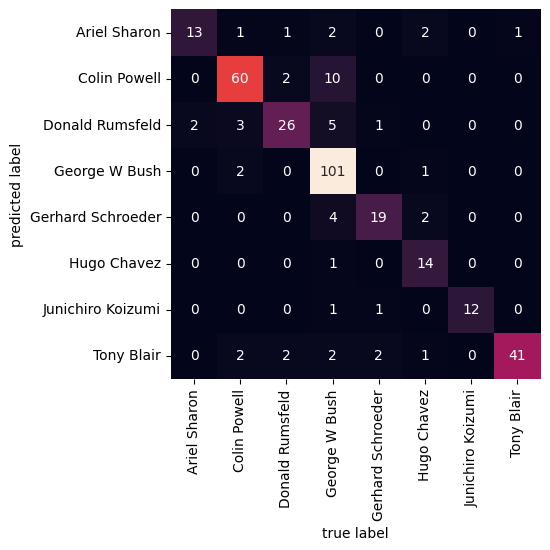

In [24]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(ytest, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

Esto nos ayuda a hacernos una idea de qué etiquetas pueden confundir al estimador.

Para una tarea de reconocimiento facial en el mundo real, en la que las fotos no vienen precortadas en bonitas cuadrículas, la única diferencia en el esquema de clasificación facial es la selección de características: sería necesario utilizar un algoritmo más sofisticado para encontrar los rostros y extraer características que sean independientes de la pixelación.     

Para este tipo de aplicación, una buena opción es utilizar OpenCV, que, entre otras cosas, incluye implementaciones preentrenadas de herramientas de extracción de características de última generación para imágenes en general y rostros en particular.